In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np

# Load the datasets
try:
    train_df = pd.read_csv('/content/sample_data/mnist_train_small.csv')
    test_df = pd.read_csv('/content/sample_data/mnist_test.csv')
except FileNotFoundError:
    print("Error: MNIST CSV files not found. Please ensure they are in /content/sample_data/")
    raise

# Separate features (images) and labels
# Assuming the first column is the label and the rest are pixel values
# Adjust '7' if your CSV header is different for the label column
y_train = train_df.iloc[:, 0].values
train_images = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
test_images = test_df.iloc[:, 1:].values

# Reshape and normalize images
# MNIST images are 28x28, so reshape from 784 (28*28) to (28, 28, 1) for CNN input
train_images = train_images.reshape(-1, 28, 28, 1).astype('float32') / 255.0
test_images = test_images.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Convert labels to appropriate type (sparse_categorical_crossentropy expects integers)
y_train = y_train.astype('int')
y_test = y_test.astype('int')

print("MNIST dataset loaded and preprocessed successfully.")
print(f"Train images shape: {train_images.shape}, Train labels shape: {y_train.shape}")
print(f"Test images shape: {test_images.shape}, Test labels shape: {y_test.shape}")





MNIST dataset loaded and preprocessed successfully.
Train images shape: (19999, 28, 28, 1), Train labels shape: (19999,)
Test images shape: (9999, 28, 28, 1), Test labels shape: (9999,)


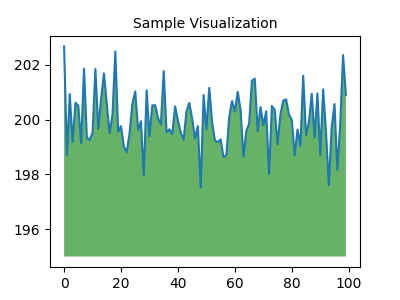

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)